In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!pip install yt-dlp


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.3/180.3 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 49.0 MB/s eta 0:00:00


# Creating .vtt File

In [4]:
!yt-dlp --write-auto-subs --sub-lang en --skip-download "https://youtu.be/ZMnEWJARaUg?si=Sy0OHiwk5qtU9w0l"


[youtube] Extracting URL: https://youtu.be/ZMnEWJARaUg?si=Sy0OHiwk5qtU9w0l
[youtube] ZMnEWJARaUg: Downloading webpage
[youtube] ZMnEWJARaUg: Downloading android sdkless player API JSON
[youtube] ZMnEWJARaUg: Downloading web safari player API JSON
[youtube] ZMnEWJARaUg: Downloading m3u8 information
[info] ZMnEWJARaUg: Downloading subtitles: en
[info] ZMnEWJARaUg: Downloading 1 format(s): 399+251
[info] Writing video subtitles to: 2 Hours of Captivating Nature Footage Narrated by David Attenborough ｜ BBC Earth [ZMnEWJARaUg].en.vtt
[download] Destination: 2 Hours of Captivating Nature Footage Narrated by David Attenborough ｜ BBC Earth [ZMnEWJARaUg].en.vtt
[download] 100% of  325.63KiB in 00:00:00 at 5.37MiB/s


In [5]:
!ls


'2 Hours of Captivating Nature Footage Narrated by David Attenborough ｜ BBC Earth [ZMnEWJARaUg].en.vtt'
 drive
 sample_data


In [9]:
!mv "2 Hours of Captivating Nature Footage Narrated by David Attenborough ｜ BBC Earth [ZMnEWJARaUg].en.vtt" /content/drive/MyDrive/


In [10]:
!ls /content/drive/MyDrive/


 2022-2-60-043_Lab03.ipynb
 2022-2-60-047_LAB04.ipynb
'2022_2_60_047_Lab06 (1).ipynb'
 2022-2-60-047_Lab06.ipynb
 2022_2_60_047_Lab06.ipynb
 2022-2-60-047_Lab07.ipynb
'2022-2-60-047_Lab08 (1).ipynb'
 2022-2-60-047_Lab08.ipynb
'2 Hours of Captivating Nature Footage Narrated by David Attenborough ｜ BBC Earth [ZMnEWJARaUg].en.vtt'
 405
 adult_income.csv
 adult_income.ipynb
 Airline_customer_satisfaction.csv
'archive (10)'
'archive (11)'
'archive (4)'
'archive (5)'
'archive (7)'
 Basic_Plotting.ipynb
 Cellphone.csv
'cinema_hall_ticket_sales (1).csv'
 CNN_Lab7
 Colab_Compatible_ML_Pipeline.ipynb
'Colab Notebooks'
 comments.txt
 concrete+compressive+strength.zip
 Concrete_Data.csv
 Concrete_Data.xls
 CSE303
'CSE 303 (DMIM) (ALL)'
'CSE 303 (DMIM) (ALL).zip'
 CSE303_Lab_4_Basic_Pandas.ipynb
 CSE303_Numpy.ipynb
 cse487.ipynb
'CustomCNN_CSE366 (1).ipynb'
'data (1).csv'
'decision_tree (1).ipynb'
 Deepfake_Project
'diabetes (2).csv'
 diabetes.csv
 diabetes_data.csv
 Final_Code475.ipynb
 Final_ML.i

In [14]:
!find / -name "*.vtt"


find: ‘/proc/69/task/69/net’: Invalid argument
find: ‘/proc/69/net’: Invalid argument
find: ‘/proc/1015/task/1015/net’: Invalid argument
find: ‘/proc/1015/net’: Invalid argument
/content/drive/MyDrive/2 Hours of Captivating Nature Footage Narrated by David Attenborough ｜ BBC Earth [ZMnEWJARaUg].en.vtt


# Renaming File to "captions.vtt"

In [20]:
!mv "/content/drive/MyDrive/2 Hours of Captivating Nature Footage Narrated by David Attenborough ｜ BBC Earth [ZMnEWJARaUg].en.vtt" /content/drive/MyDrive/captions.vtt


# For Loading the Captions

In [22]:
def load_vtt_captions(filepath='/content/drive/MyDrive/captions.vtt'):
    captions = []
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if '-->' not in line and line and not line.isdigit() and 'WEBVTT' not in line:
                captions.append(line)
    return captions

captions = load_vtt_captions('/content/drive/MyDrive/captions.vtt')
print(f"Loaded {len(captions)} caption lines.")
print(captions[:5])  # Display the first 5 caption lines for inspection


Loaded 2681 caption lines.
['Kind: captions', 'Language: en', 'And<00:00:05.680><c> now</c><00:00:06.160><c> the</c><00:00:06.400><c> snakes</c><00:00:07.040><c> are</c><00:00:07.279><c> on</c><00:00:07.440><c> the</c><00:00:07.680><c> alert.</c>', 'And now the snakes are on the alert.', 'And now the snakes are on the alert.']


# For Loading the Comments

In [26]:
comments = load_raw_comments('/content/drive/MyDrive/comments.txt')


In [30]:
comments = load_raw_comments('/content/drive/MyDrive/comments.txt')
print(f"Loaded {len(comments)} comments.")
print(comments[:5])  # Display the first 5 comments for inspection


Loaded 66 comments.
['That bison knocking down the young one like "Sorry lil homie you gotta take one for the team."', 'Therapy is expensive. So, I listen to Sir David Attenborough.', "I never get tired of hearing Sir David Attenborough's voice and his crystal clear narration.", 'Who knew a tiny mantis could channel its inner kung fu master? Nature’s bluff game is strong with this one', 'Those snakes after the iguanas is like hell on earth']


# Preprocessing Data

In [31]:
import re

def clean_text(text):
    # Remove unwanted characters, punctuation, or extra spaces
    text = re.sub(r'[^\w\s]', '', text)
    return text.lower()

# Clean the comments and captions
cleaned_comments = [clean_text(comment) for comment in comments]
cleaned_captions = [clean_text(caption) for caption in captions]


# Histogram

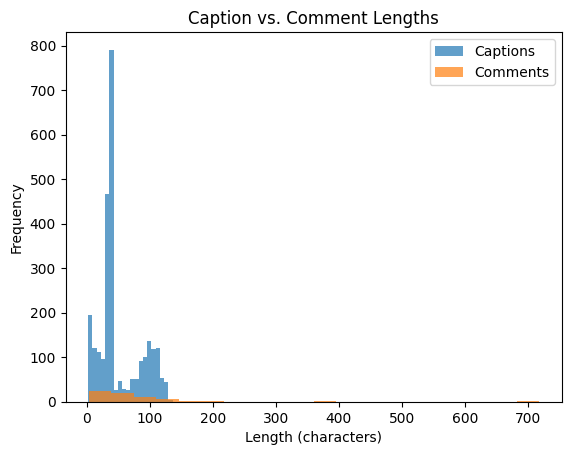

In [32]:
import matplotlib.pyplot as plt

# Calculating lengths
caption_lengths = [len(caption) for caption in cleaned_captions]
comment_lengths = [len(comment) for comment in cleaned_comments]

# Plotting histograms
plt.hist(caption_lengths, bins=20, alpha=0.7, label='Captions')
plt.hist(comment_lengths, bins=20, alpha=0.7, label='Comments')
plt.legend()
plt.xlabel('Length (characters)')
plt.ylabel('Frequency')
plt.title('Caption vs. Comment Lengths')
plt.show()


# TTR

In [33]:
def type_token_ratio(lines):
    words = [word for line in lines for word in line.split()]
    unique = set(words)
    return len(unique) / len(words) if words else 0

# Calculating TTR for captions and comments
caption_ttr = type_token_ratio(cleaned_captions)
comment_ttr = type_token_ratio(cleaned_comments)

print(f"Caption TTR: {caption_ttr}")
print(f"Comment TTR: {comment_ttr}")


Caption TTR: 0.4562001543606895
Comment TTR: 0.48183760683760685


# Top-N Word Frequency (After Stopword Removal)

In [34]:
from collections import Counter

# Defining stopwords
stopwords = set(['the', 'and', 'a', 'is', 'in', 'to', 'of', 'that', 'it', 'on', 'for', 'with', 'as', 'this', 'was', 'but', 'are', 'not', 'be', 'at', 'by', 'an', 'if', 'or', 'from', 'so', 'we'])

def top_n_words(lines, n=20):
    words = [word for line in lines for word in line.split() if word not in stopwords]
    return Counter(words).most_common(n)

# Top 20 frequent words for captions and comments
top_caption_words = top_n_words(cleaned_captions)
top_comment_words = top_n_words(cleaned_comments)

print("Top 20 Caption Words:", top_caption_words)
print("Top 20 Comment Words:", top_comment_words)


Top 20 Caption Words: [('music', 124), ('gtgt', 102), ('its', 98), ('their', 91), ('they', 84), ('one', 70), ('thec', 66), ('can', 65), ('now', 56), ('has', 54), ('have', 54), ('them', 54), ('will', 48), ('she', 42), ('here', 40), ('her', 40), ('these', 39), ('just', 38), ('he', 34), ('there', 32)]
Top 20 Comment Words: [('you', 18), ('i', 13), ('david', 9), ('life', 9), ('attenborough', 8), ('one', 7), ('sir', 7), ('all', 7), ('like', 6), ('when', 6), ('just', 6), ('narration', 5), ('who', 5), ('those', 5), ('every', 5), ('would', 5), ('amazing', 5), ('video', 5), ('voice', 4), ('its', 4)]
